In [1]:
import nibabel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.data_utils import download_data, count_file_type, build_paths_df, build_dataframe_to_split
from src.image_analysis import enrich_dataframe, intensity_statistics
from src.lesion_analysis import mask_features, lesion_volume_quartiles
from src.visualization import visualize_all_patient_images, visualize_mri_with_mask, visualize_one_slice

In [2]:
# Загрузка датасета
dataset_path = download_data()
dataset_path

100%|██████████| 1.59G/1.59G [02:34<00:00, 11.1MB/s]

Extracting files...


WindowsPath('C:/project_data/ISLES-2022/ISLES-2022')

### Общее ознакомление с датасетом

In [3]:
# Подсчет количества файлов по расширениям
extension_counts = count_file_type(dataset_path)

print('Количество файлов по расширениям:')
for ext, count in sorted(extension_counts.items(), key=lambda item: item[1], reverse=True):
    print(f'{ext}: {count}')

Количество файлов по расширениям:
.nii: 1000
.json: 433
.png: 250
without_extension: 2
.tsv: 1


В датасете имеются:
* 1000 файлов формата NIfTI, из которых 750 МР-изображений (по 250 снимков ADC, DWI и FLAIR) и 250 масок сегментации очага инсульта
* 433 JSON файлов, один из которых содержит краткую информацию о датасете, а остальные содержат в себе метаданные МРТ-снимков. То есть для 58% МР-изображений имеется дополнительный файл с их метаданными
* 250 PNG файлов, на которых представлены отдельные слайды МР-изображения, с наложенной на него маской сегментации
* TSV файл, содержащий данные о пациентах (пол, возраст и вес)
* 2 файла без расширения: README датасета и текст лицензии на его использование

Так как для каждого пациента имеется несколько разных протоколов МРТ-снимков, это необходимо учесть при разбиении данных на train и test и не допустить распространение снимков одного пациента на разные подвыборки.

In [4]:
# Путь к МР-изображению
mri = (
        dataset_path / 'sub-strokecase0001' / 'ses-0001' /
       'dwi' / 'sub-strokecase0001_ses-0001_dwi.nii' /
       'sub-strokeperf0041_ses-20180528_ornt-2iso_skull-stripped_sequ-307_dwi.nii'
       )

# Вывод метаданных
header = nibabel.load(mri).header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 112 112  73   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float64
bitpix          : 64
slice_start     : 0
pixdim          : [-1.  2.  2.  2.  0.  0.  0.  0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : aligned
sform_code      : scanner
quatern_b       : 0.010537628084421158
quatern_c       : -0.9994957447052002
quatern_d       : -0.01939394511282444
qoffset_x       : 110.20133209228516
qoffset_y       : -111.78

In [5]:
# Путь к маске сегментации
mask = (
        dataset_path / 'derivatives' / 'sub-strokecase0001' /
       'ses-0001' / 'sub-strokecase0001_ses-0001_msk.nii'
       )

# Вывод метаданных
header = nibabel.load(mask).header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 112 112  73   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.  2.  2.  2.  0.  0.  0.  0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : aligned
sform_code      : scanner
quatern_b       : 0.010537628084421158
quatern_c       : -0.9994957447052002
quatern_d       : -0.01939394511282444
qoffset_x       : 110.20133209228516
qoffset_y       : -111.780

Метаданные МР-изображений и масок сегментации не содержат id пациента, а также явного указания на то, какой это протокол МРТ или является этот файл маской. Возможно эту информацию можно получить исходя из некоторых из указанных в метаданных параметров, но этот вариант представляется слишком сложным и проще получить эту информацию исходя из названий папок, в которых хранятся эти изображения (так как не все изображения содержат в своем названии id пациента и протокол сканирования). Использование JSON метаданных для этой цели нерационально, так как они представлены не для всех снимков (к тому же нет гарантии, что в них содержится эта информация)

### Сбор данных

In [6]:
# Формирование датафрейма путей к .nii файлам
paths_df = build_paths_df(dataset_path)
paths_df.head()

,file_path,patient_id,label
0,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,250,flair
1,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,250,adc
2,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,250,dwi
3,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,249,flair
4,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,249,adc


In [7]:
print('Проверка верности данных в датафрейме')
print(f"\n{'=' * 40}\n")

print('Количество пропущенных значений:\n')
print(paths_df.isna().sum())
print(f"\n{'=' * 40}\n")

print('Распределение .nii файлов по признаку label:\n')
print(paths_df.label.value_counts())
print(f"\n{'=' * 40}\n")

print('Минимальное и максимальное значения id пациента:\n')
print(f'Min: {paths_df.patient_id.min()}')
print(f'Max: {paths_df.patient_id.max()}')
print(f"\n{'=' * 40}\n")

print('Уникальные значения количества .nii файлов на пациента:\n')
print(paths_df.patient_id.value_counts().unique())

Проверка верности данных в датафрейме


Количество пропущенных значений:

file_path     0
patient_id    0
label         0
dtype: int64


Распределение .nii файлов по признаку label:

label
flair    250
adc      250
dwi      250
mask     250
Name: count, dtype: int64


Минимальное и максимальное значения id пациента:

Min: 1
Max: 250


Уникальные значения количества .nii файлов на пациента:

[4]


Датафрейм собран верно, так как:
1. Пропущенных значений нет.
2. Для каждого протокола и маски имеется по 250 файлов.
3. ID пациента укладывается в границы от 1 до 250.
4. Для каждого пациента представлено по 4 файла.

In [8]:
# Обогащение датафрейма метаданными .nii файлов
enriched_df = enrich_dataframe(paths_df)
enriched_df.head()

,file_path,patient_id,label,image_dimension,image_X_size,image_Y_size,image_Z_size,voxel_volume_mm3,affine_matrix,data_type
0,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,250,flair,3,224,256,24,4.431152,"((-0.8535763025283813, 0.098762147128582, -0.0...",int16
1,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,250,adc,3,128,128,25,15.498048,"((-1.7847503423690796, 0.2065027356147766, -0....",int16
2,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,250,dwi,3,128,128,25,15.498048,"((-1.7847503423690796, 0.2065027356147766, -0....",int16
3,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,249,flair,3,224,256,24,4.431152,"((-0.8560489416122437, 0.06286430358886719, 0....",int16
4,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,249,adc,3,128,128,25,15.498048,"((-1.7899205684661865, 0.13144348561763763, 0....",int16


### Анализ МР-изображений

In [9]:
print('Размерности изображений:\n')
print(enriched_df.groupby('label').image_dimension.value_counts())
print(f"\n{'=' * 40}\n")

print('Количество уникальных матриц преобразований:\n')
print(enriched_df.affine_matrix.nunique())
print(f"\n{'=' * 40}\n")

print('Типы данных файлов:\n')
print(enriched_df.groupby('label').data_type.value_counts())

Размерности изображений:

label  image_dimension
adc    3                  250
dwi    3                  250
flair  3                  250
mask   3                  250
Name: count, dtype: int64


Количество уникальных матриц преобразований:

497


Типы данных файлов:

label  data_type
adc    float64      191
       int16         59
dwi    float64      191
       int16         59
flair  float32      191
       int16         59
mask   uint16       181
       int16         47
       float64       22
Name: count, dtype: int64


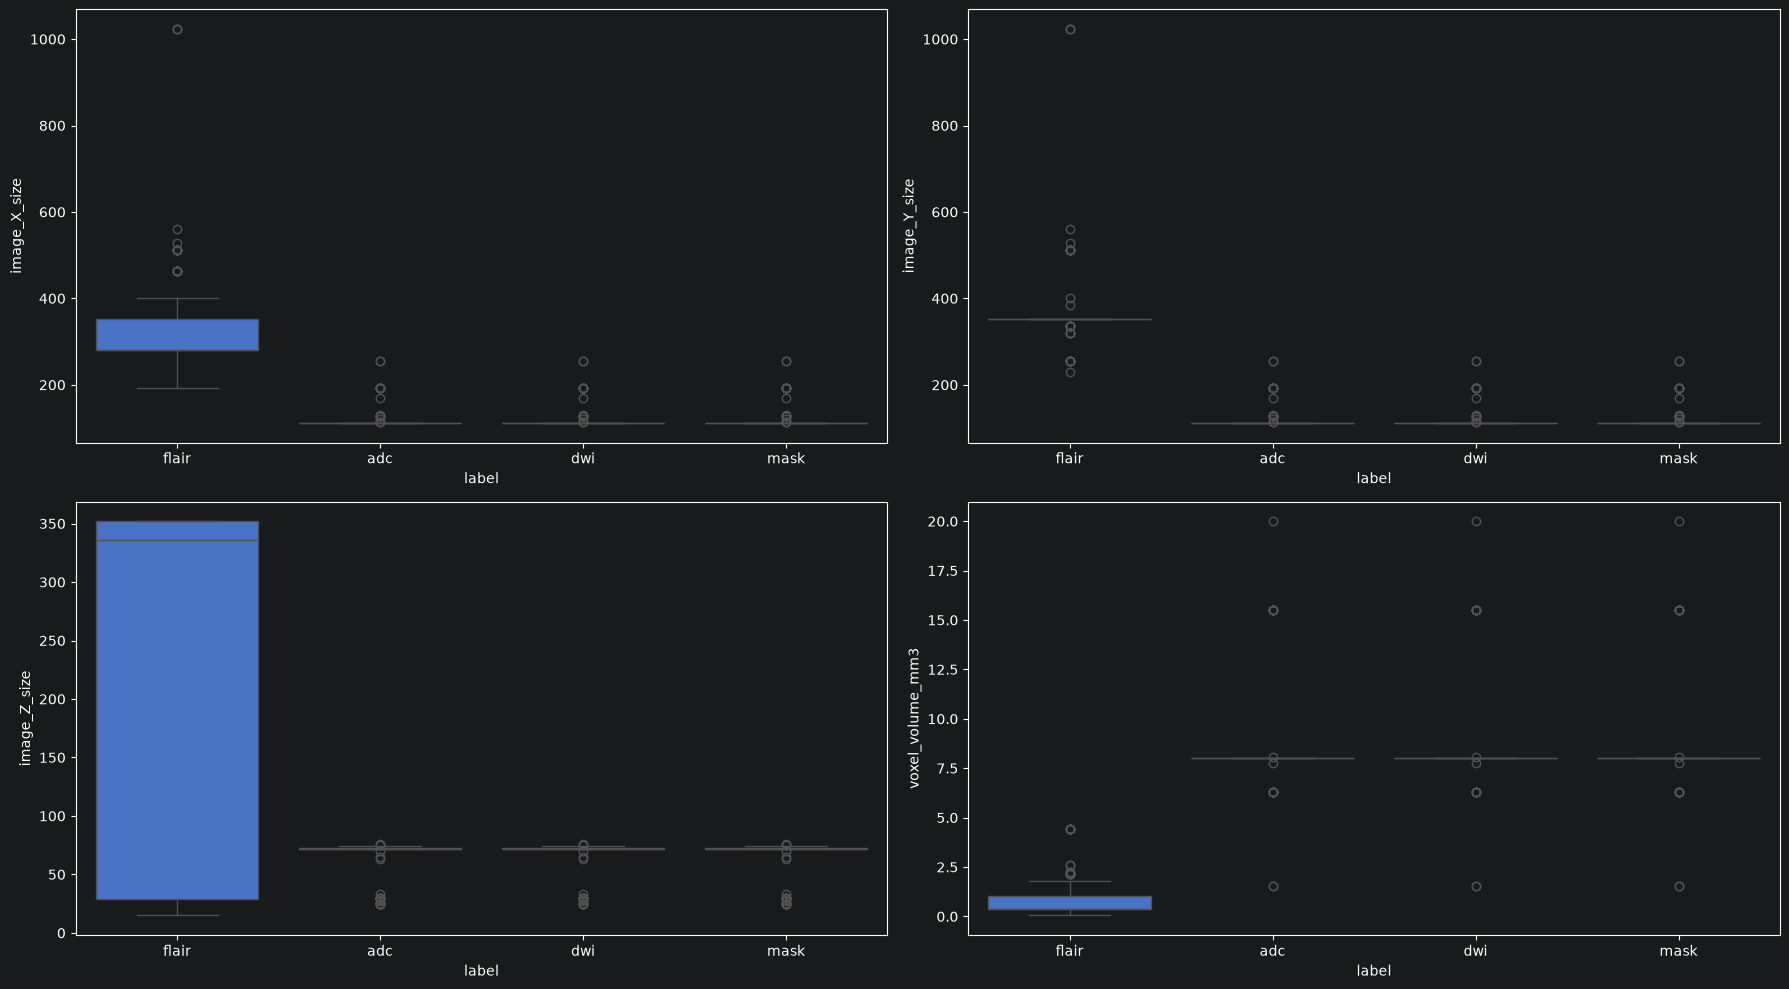

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, col in zip(axes.flatten(), ['image_X_size', 'image_Y_size', 'image_Z_size', 'voxel_volume_mm3']):
    sns.boxplot(data=enriched_df, x='label', y=col, ax=ax)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

При анализе метаданных снимков и масок обнаруживается, что:
1. Снимки разнородны по своим основным характеристиками. Вероятно данный датасет был сформирован путем сбора снимков от разных учреждений/томографов, характеристики съемок между которыми не согласованы.
2. Все снимки и маски трехмерные.
3. Распределение размеров изображений по осям и объема вокселей у ADC, DWI и масок концентрируется на одном значении с небольшим количеством выбросов.  Также стоит отметить, что все эти распределения одинаковы у всех этих групп, что говорит о том, что маски строились на основании ADC или DWI.
4. FLAIR снимки, в сравнении с другими группами, более вариативны по размерам по осям и объемам вокселей. Особенно это прослеживается для общего распределения оси Z, а также по выбросу для осей X и Y значительно удаленному относительно других изображений. Отличия распределений данного протокола от других объясняется иными параметрами сканирования
5. Прослеживается логичная закономерность: FLAIR снимки в среднем более протяженные по осям, но физический объем их вокселей в среднем меньше.
6. Изображения и маски обладают большим разнообразием матриц преобразования.
7. Типы данных также различаются, что потребует приведения к одному типу данных. Особое внимание привлекают маски с типом данных float64, необходимо ознакомиться с ними подробнее.

In [11]:
# Вывод самых протяженных по осям изображений
enriched_df.sort_values('image_X_size', ascending=False).head()

,file_path,patient_id,label,image_dimension,image_X_size,image_Y_size,image_Z_size,voxel_volume_mm3,affine_matrix,data_type
585,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,55,flair,3,1024,1024,230,0.054932,"((0.23375584185123444, -0.012679476290941238, ...",float32
507,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,81,flair,3,1024,1024,230,0.054932,"((0.22964370250701904, -0.03589601069688797, -...",float32
327,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,141,flair,3,1024,1024,230,0.054932,"((0.2342948168516159, -0.0025307079777121544, ...",float32
474,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,92,flair,3,560,560,33,0.918367,"((-0.4245019257068634, -0.05174678564071655, 0...",float32
510,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,80,flair,3,528,528,29,0.953109,"((-0.4364706575870514, -0.01070837676525116, -...",float32


In [12]:
# Вывод изображений с наименьшим объемом вокселей
enriched_df.sort_values('voxel_volume_mm3').head()

,file_path,patient_id,label,image_dimension,image_X_size,image_Y_size,image_Z_size,voxel_volume_mm3,affine_matrix,data_type
585,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,55,flair,3,1024,1024,230,0.054932,"((0.23375584185123444, -0.012679476290941238, ...",float32
507,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,81,flair,3,1024,1024,230,0.054932,"((0.22964370250701904, -0.03589601069688797, -...",float32
327,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,141,flair,3,1024,1024,230,0.054932,"((0.2342948168516159, -0.0025307079777121544, ...",float32
261,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,163,flair,3,281,352,352,0.356629,"((0.7053993344306946, 0.08082142472267151, -0....",float32
522,C:\project_data\ISLES-2022\ISLES-2022\sub-stro...,76,flair,3,281,352,352,0.358911,"((0.7113494277000427, -0.011954979971051216, 0...",float32


Всего есть 3 FLAIR изображения с размерами по осям X и Y 1024x1024. Соблюдается обнаруженная закономерность: эти изображения обладают наименьшим объемом вокселя (объем их вокселей в 7 раз меньше, чем у следующих за ними изображений с минимальными объемами вокселей). Однако все-равно стоит визуализировать одно из этих изображений, чтобы удостовериться, что с ними все в порядке

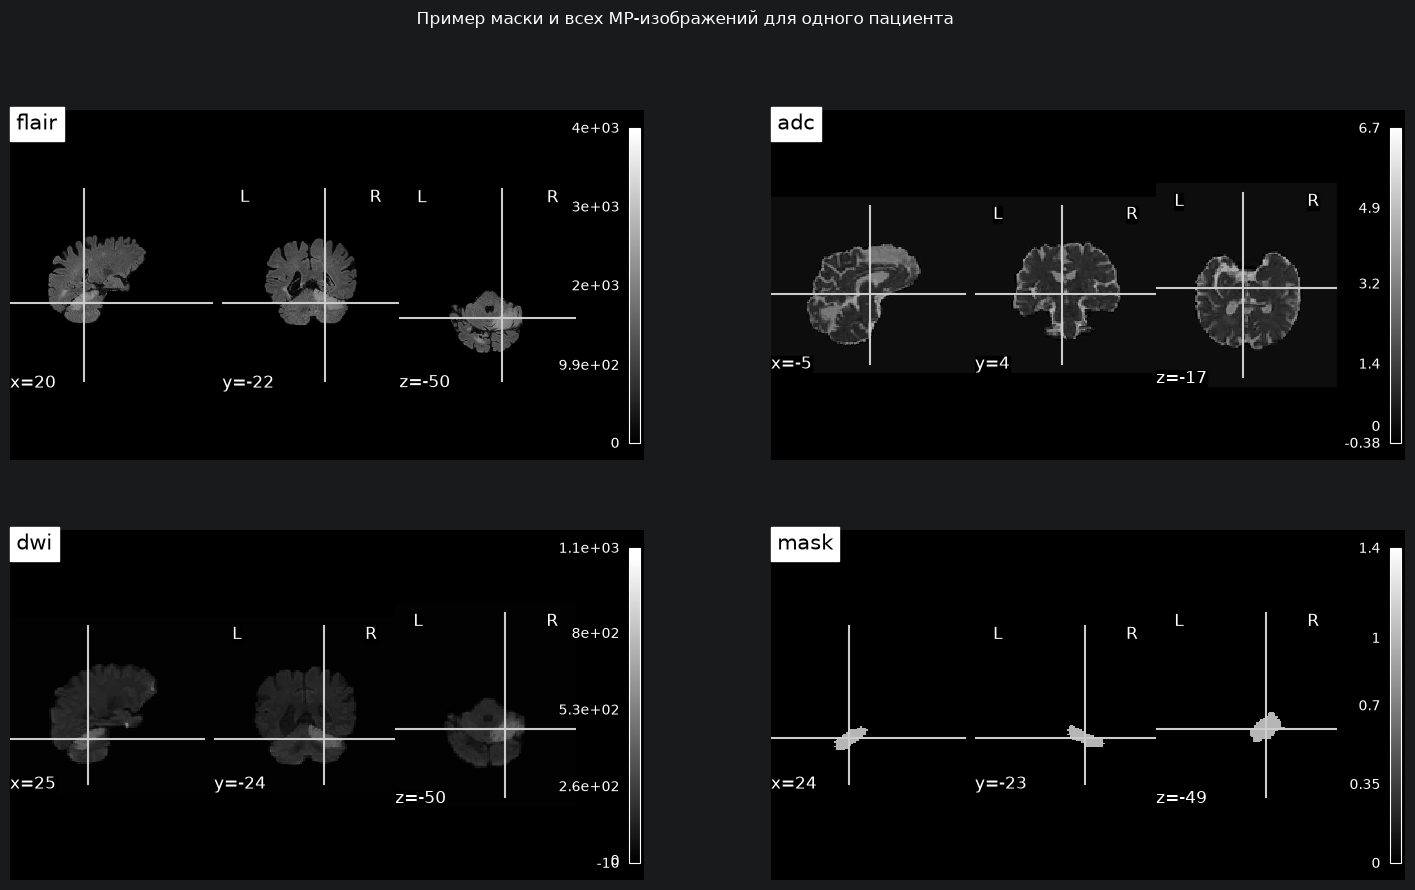

In [13]:
# Формирование датафрейма для одного пациента
patient_55_df = enriched_df[enriched_df['patient_id'] == 55]

# Вывод всех снимков и маски в трех проекциях
visualize_all_patient_images(patient_55_df)

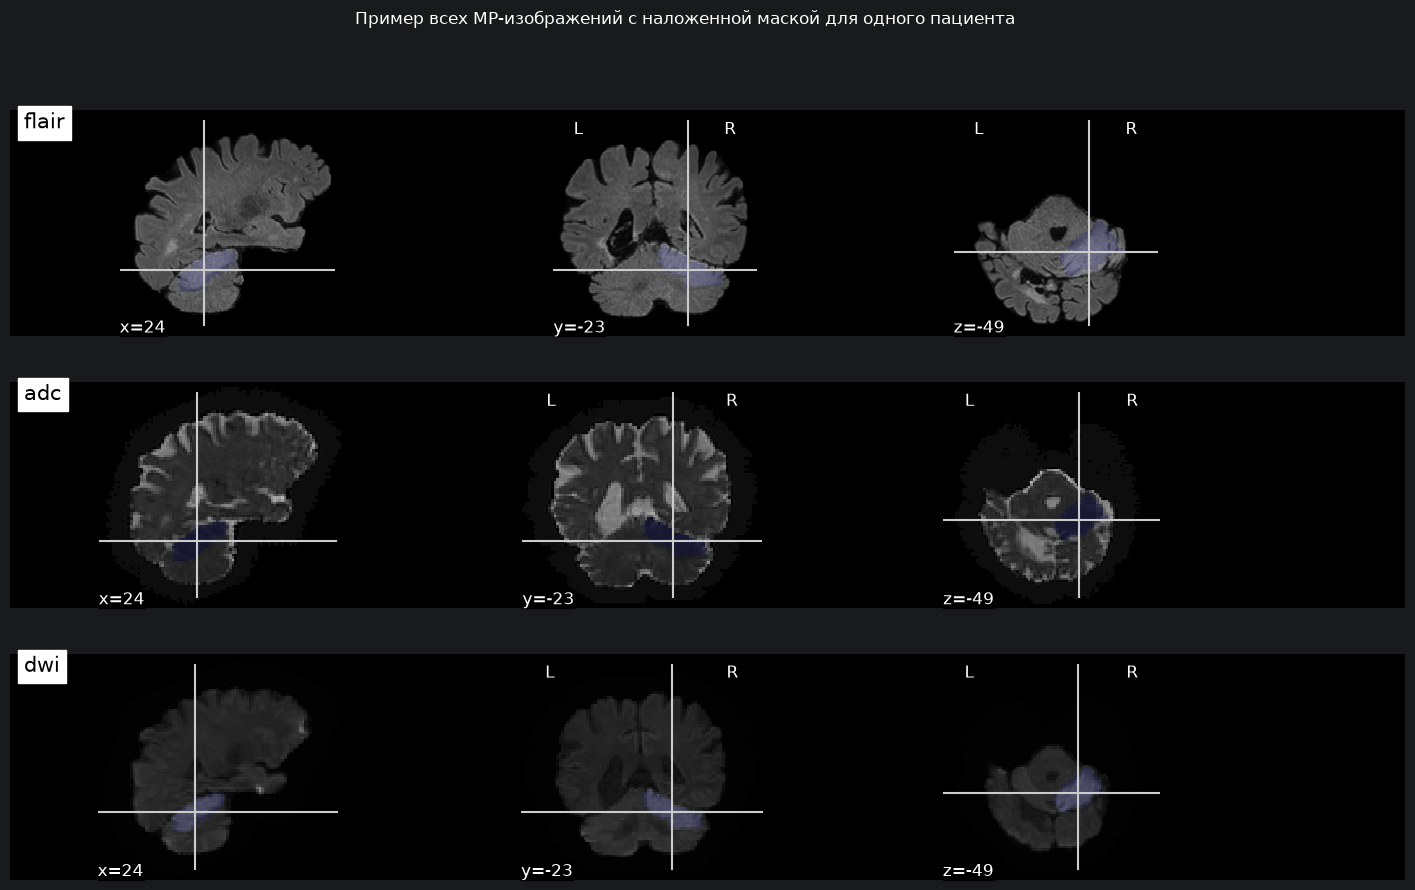

In [14]:
# Формирование датафрейма для одного пациента
patient_mri = patient_55_df[patient_55_df['label'] != 'mask']
patient_mask = patient_55_df[patient_55_df['label'] == 'mask']

# Вывод всех снимков с наложенной маской в трех проекциях
visualize_mri_with_mask(patient_mri, patient_mask)

Изображение визуализируются правильно. Маска сегментации накладывается на FLAIR изображение в области, на которой визуализируется ишемическое поражение, соответствующее поражению на DWI и ADC

### Анализ масок сегментации

In [15]:
# Формирование датасета из масок с типом данных float64
strange_masks = enriched_df[(enriched_df['label'] == 'mask') & (enriched_df['data_type'] == 'float64')]

# Множество для сохранения уникальных значений
uni = set()

# Получение уникальных значений из масок сегментации
for row in strange_masks.itertuples():

    # Чтение масок
    img = nibabel.load(row.file_path)

    # Получение внутреннего содержания
    data = img.get_fdata()

    # Получение уникальных значений и добавление во множество
    unique_values = np.unique(data)
    uni.update(unique_values)

print(uni)

{np.float64(0.0), np.float64(1.0)}


Все маски с типом данных float64 представляют собой классические маски сегментаций и не потребуют трансформации для последующего анализа

In [17]:
# Получение дополнительных признаков из масок сегментации
full_mask_df = mask_features(enriched_df)
full_mask_df.head()

,file_path,patient_id,label,image_dimension,image_X_size,image_Y_size,image_Z_size,voxel_volume_mm3,affine_matrix,data_type,total_volume_cm3,n_lesions
0,C:\project_data\ISLES-2022\ISLES-2022\derivati...,250,mask,3,128,128,25,15.498048,"((-1.7847503423690796, 0.2065027356147766, -0....",int16,8.027989,10
1,C:\project_data\ISLES-2022\ISLES-2022\derivati...,249,mask,3,128,128,25,15.498048,"((-1.7899205684661865, 0.13144348561763763, 0....",int16,11.251583,1
2,C:\project_data\ISLES-2022\ISLES-2022\derivati...,248,mask,3,192,192,30,6.302084,"((-1.1246931552886963, 0.16006755828857422, 0....",uint16,16.013597,245
3,C:\project_data\ISLES-2022\ISLES-2022\derivati...,247,mask,3,112,112,72,8.000000,"((-1.9964040517807007, -0.08442528545856476, -...",uint16,18.256000,16
4,C:\project_data\ISLES-2022\ISLES-2022\derivati...,246,mask,3,112,112,72,8.000000,"((-1.9800101518630981, 0.044606395065784454, -...",uint16,216.256000,17


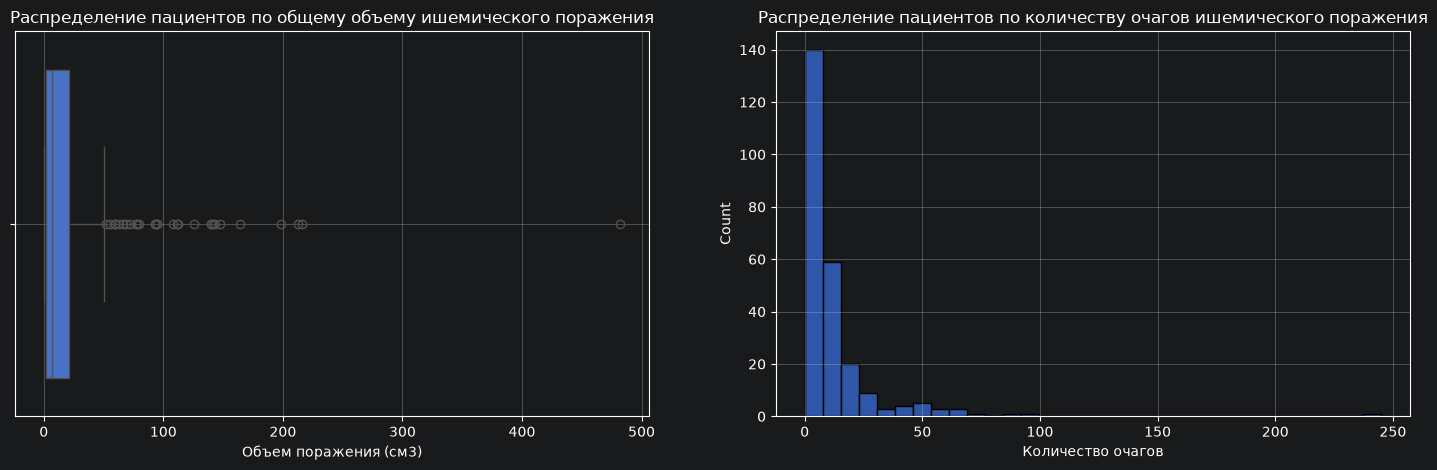

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(data=full_mask_df, x='total_volume_cm3', ax=axes[0])
axes[0].set_title('Распределение пациентов по общему объему ишемического поражения')
axes[0].set_xlabel('Объем поражения (см3)')
axes[0].grid(True)

sns.histplot(data=full_mask_df, x='n_lesions', ax=axes[1])
axes[1].set_title('Распределение пациентов по количеству очагов ишемического поражения')
axes[1].set_xlabel('Количество очагов')
axes[1].grid(True)

plt.show()

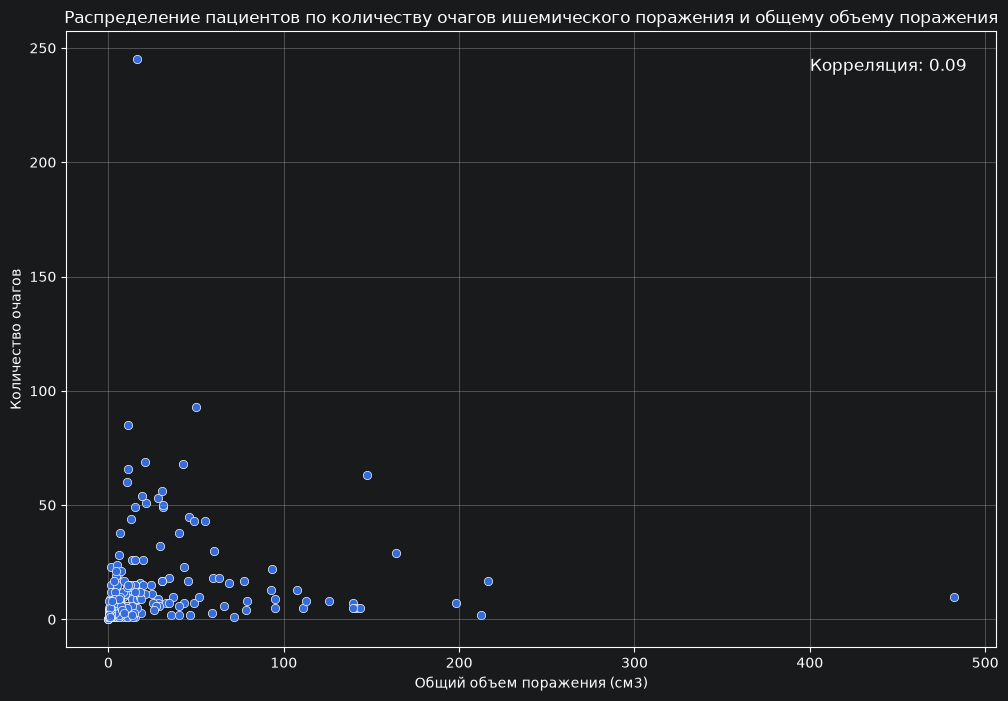

In [20]:
plt.figure(figsize=(12, 8))

# Расчет корреляции общего объема поражения и количества очагов
corel = full_mask_df['total_volume_cm3'].corr(full_mask_df['n_lesions'])

sns.scatterplot(data=full_mask_df, x='total_volume_cm3', y='n_lesions')
plt.title('Распределение пациентов по количеству очагов ишемического поражения и общему объему поражения')
plt.xlabel('Общий объем поражения (см3)')
plt.ylabel('Количество очагов')
plt.text(x=400, y=240, s=f'Корреляция: {corel:.2f}', fontsize=12)
plt.grid(True)

plt.show()

Рассмотрим распределение отдельных очагов по объему

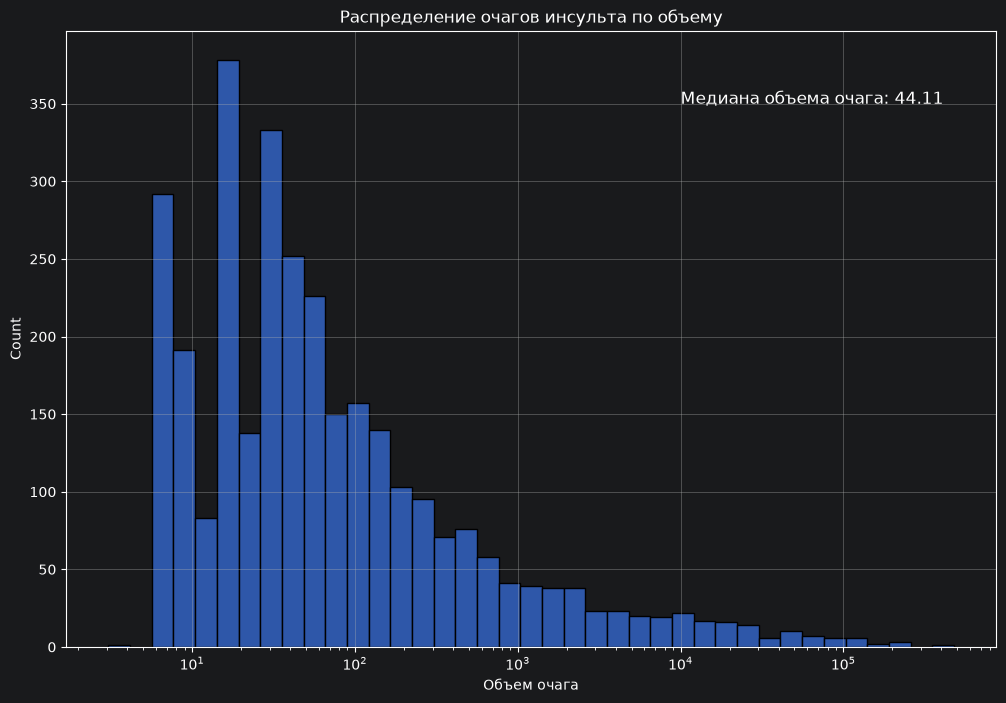

In [34]:
lesion_volumes, median = lesion_volume_quartiles(enriched_df)

plt.figure(figsize=(12, 8))

sns.histplot(lesion_volumes, log_scale=True)
plt.title('Распределение очагов инсульта по объему')
plt.xlabel('Объем очага')
plt.text(x=10000, y=350, s=f'Медиана объема очага: {median:.2f}', fontsize=12)
plt.grid(True)

Общий объем ишемического поражения у большинства пациентов составляет от 0 до 50 см3, также имеется небольшое число пациентов с объемом поражения от 50 до 220 см3 и один пациент с очень обширным поражением, объем которого близок к 500 см3. Стоит визуализировать этот экстремальный выброс

У большинства пациентов поражение представлено 1-15 очагами, у меньшего количества пациентов наблюдается от 15 до 100 очагов и у одного пациента - 250 очагов. Этот случай также стоит визуализировать

Также имеется несколько пациентов без очагов, то есть с пустыми масками сегментаций. В таком случае их необходимо выделить в отдельный класс помимо пациентов с единым очагом и пациентов с множественными очагами

Корреляция между общим объемом поражения и количеством очагов слабая, что говорит о том, что в датасете представлены случаи инсульта разного генеза, так как эти характеристики зависят от причины, локализации, степени окклюзии и других признаков

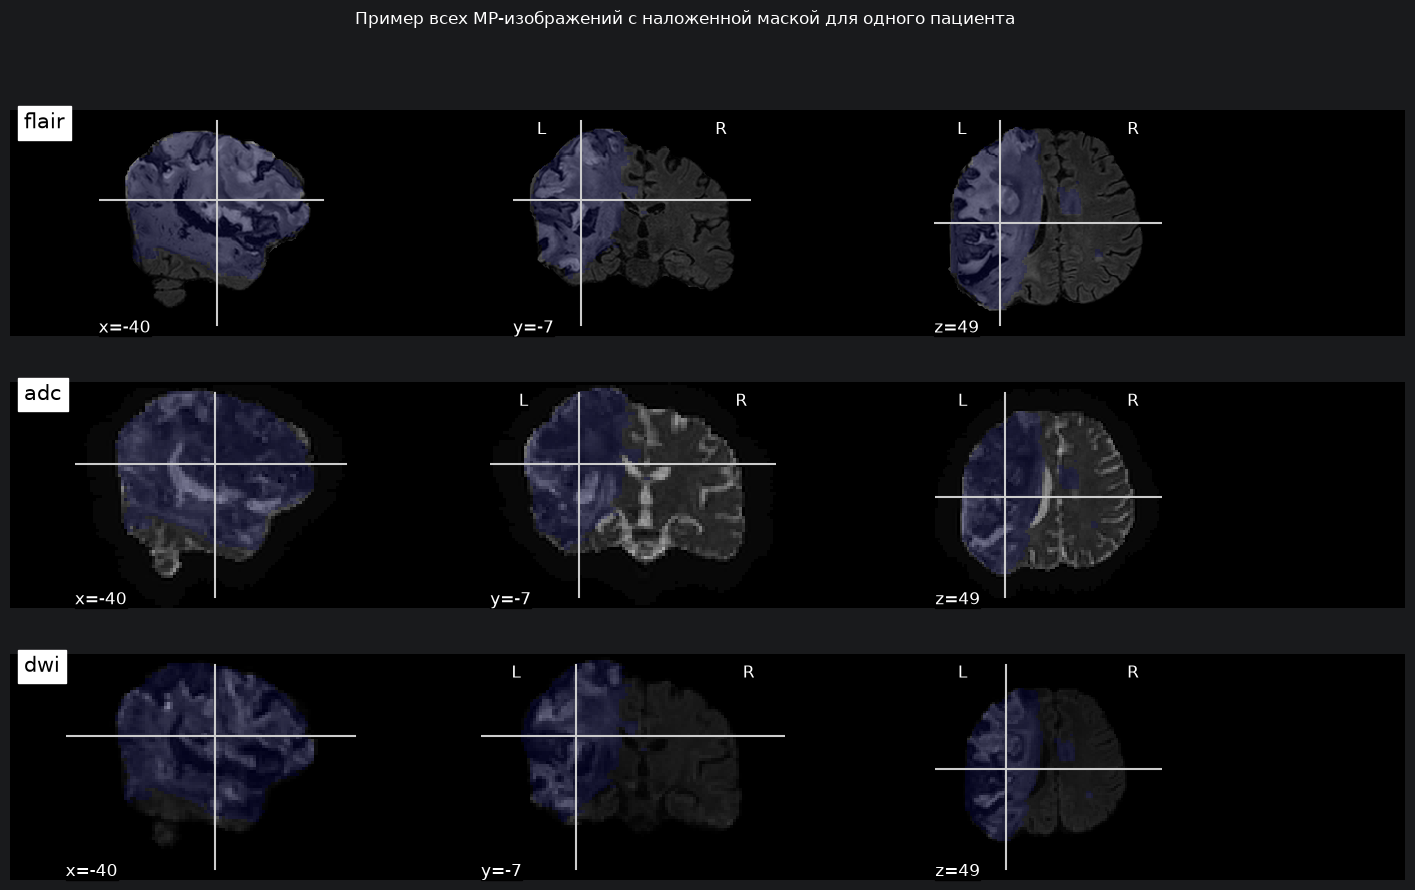

In [35]:
# Формирование датафрейма для пациента с самым крупным поражением
largest_lesion_id = full_mask_df[full_mask_df['total_volume_cm3'] > 450]['patient_id'].item()
largest_lesion_df = enriched_df[enriched_df['patient_id'] == largest_lesion_id]

# Формирование датафрейма для одного пациента
patient_mri = largest_lesion_df[largest_lesion_df['label'] != 'mask']
patient_mask = largest_lesion_df[largest_lesion_df['label'] == 'mask']

# Вывод всех снимков с наложенной маской в трех проекциях
visualize_mri_with_mask(patient_mri, patient_mask)

В пояснении к этому изображению, и в некоторых местах далее, будут высказываться предположения о клинической ситуации, необходимые для того, чтобы определиться с последующим разбиением датасета на подвыборки. Все эти предположения высказываются на основе самых вероятных причин, приводящих к имеющейся визуализации, и являются вероятностными, так как исключительно по МР-изображениям нельзя сделать точное заключение о характере ишемического поражения

На визуализации видно, что данная маска построена корректно: границы маски соответствуют границам мозга; выделенные области левого полушария в большем объеме значительно более гиперинтенсивные на DWI и FLAIR и гипоинтенсивные - на ADC, относительно соответствующих областей в правом полушарии; выделенные области левого полушария имеют нетипичную интенсивность, по сравнению с окружающей тканью, для данных областей мозга. На МР-изображениях видно очень обширное поражение в левом полушарии и небольшие поражения в правом полушарии, а также значительное увеличение борозд мозга левого полушария. С высокой вероятностью снимок показывает обширный отек возникший на фоне длительной окклюзии и последующей реперфузии крупной артерии, снабжающей левое полушарие на подострой стадии инсульта (о чем свидетельствует значительное увеличение объема левого полушария, относительно правого и расширение борозд), однако данные изображения могут показывать и острую стадию инсульта, а расширение борозд мозга является следствием перенесенных ранее заболеваний, геморрагическое перерождение инсульта. К сожалению, в датафрейме отсутствует информация о локализации окклюзии сосудов у пациентов, факте реперфузии сосудов и геморрагического перерождения, а также временные метки МРТ-сканирования после начала ишемического эпизода и после реперфузии (при ее факте), что не позволяет уверенно говорить о стадии инсульта

C:\Users\Герман\Desktop\projects\Stroke_segmetation_raw\src\visualization.py:33: UserWarning: Casting data from int16 to float32
  plotting.plot_roi(


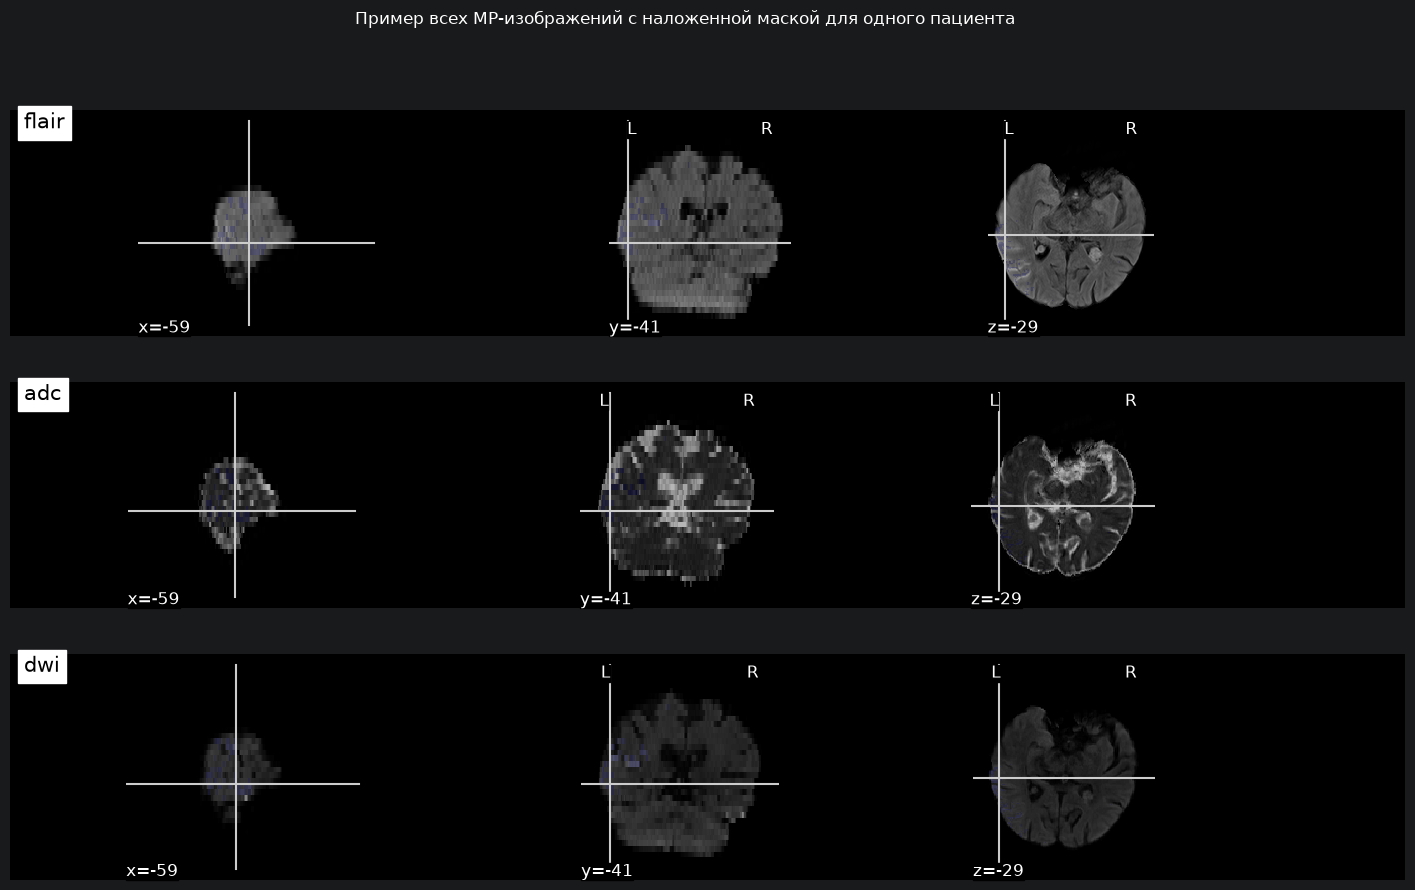

In [36]:
# Формирование датафрейма для пациента с самым крупным поражением
multifocal_lesion_id = full_mask_df[full_mask_df['n_lesions'] > 200]['patient_id'].item()
multifocal_lesion_df = enriched_df[enriched_df['patient_id'] == multifocal_lesion_id]

# Формирование датафрейма для одного пациента
patient_mri = multifocal_lesion_df[multifocal_lesion_df['label'] != 'mask']
patient_mask = multifocal_lesion_df[multifocal_lesion_df['label'] == 'mask']

# Вывод всех снимков с наложенной маской в трех проекциях
visualize_mri_with_mask(patient_mri, patient_mask)

На данных снимках визуализируется большое количество мелких очагов в левом полушарии. Для некоторых зон геперинтенсивности на FLAIR наблюдается несоответствие границ с сегментацией это объясняется или разницей в разрешении (по сравнению с ADC и DWI на основании одного из которых строилась сегментация), или тем, что это зоны пенумбры (которые не визуализируются на DWI и ADC), или и тем и другим в совокупности. Также на FLAIR изображениях присутствуют зоны гиперинтенсивности, не имеющие соответствующих аналогов на DWI и ADC, которые могут быть очагами ранее перенесенного(ых) инсульта/микроинсульта. При такой картине вероятнее всего причиной инсульта являются сосудистые патологии, приводящие к окклюзиям мелких сосудов и количество очагов острой/подострой ишемии более 200 на исходной маске сегментации не говорит о ее недостоверности, хоть и удивляет

In [37]:
print(f'Количество пустых масок: {len(full_mask_df[full_mask_df['total_volume_cm3'] == 0])}')

Количество пустых масок: 3


В датасете присутствует 3 пациента, у которых маски сегментации пустые (примерно 1% от всего числа пациентов). Стоит визуализировать все эти изображения.

C:\Users\Герман\Desktop\projects\Stroke_segmetation_raw\src\visualization.py:17: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.plot_anat(patient_df[patient_df['label'] == label]['file_path'].item(),


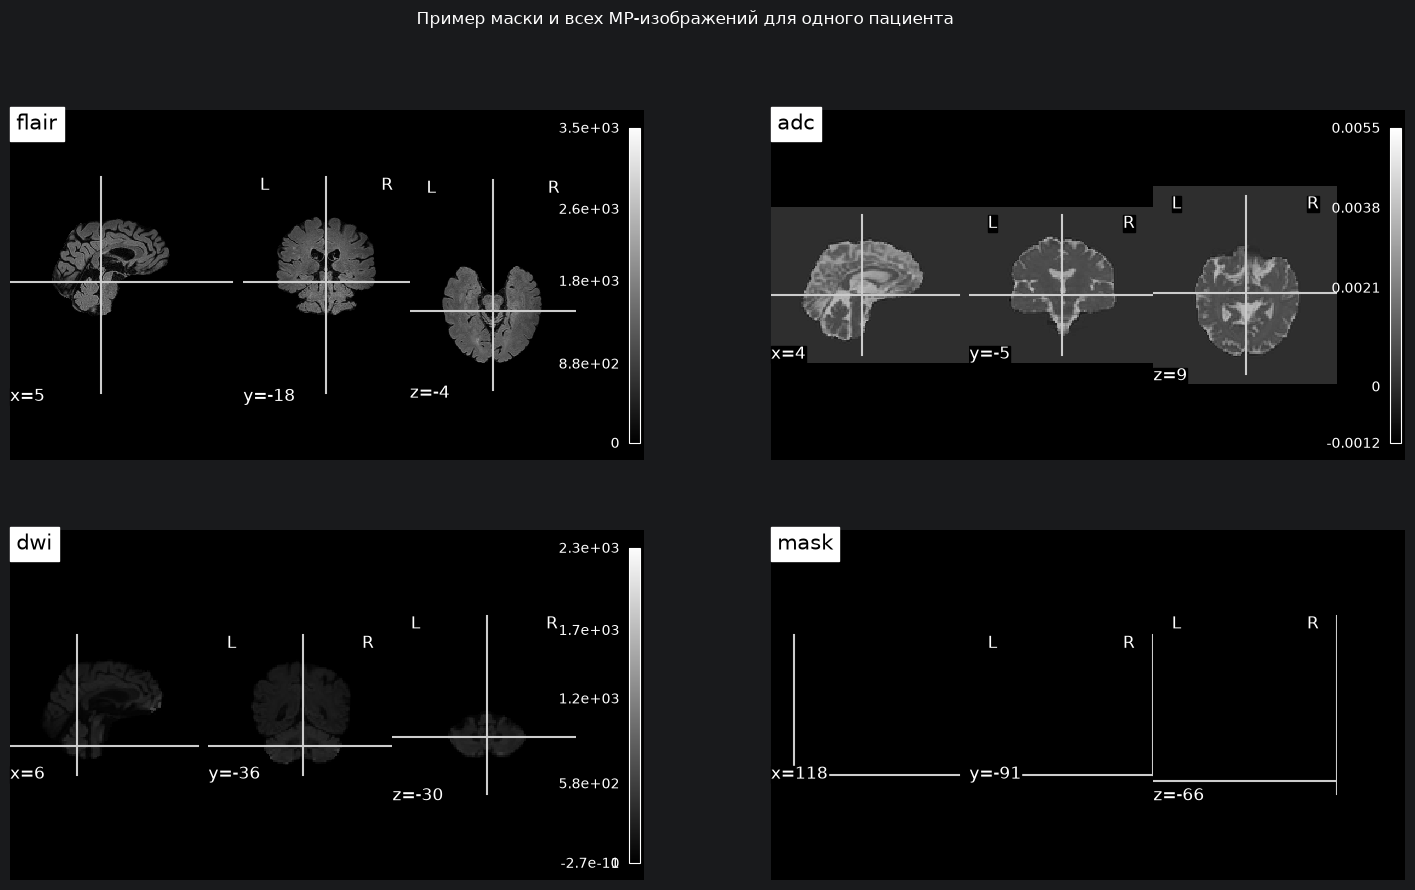

In [38]:
# Формирование датафрейма для пациента без очага
without_lesion_id = full_mask_df[full_mask_df['total_volume_cm3'] == 0].iloc[0, 1]
without_lesion_df = enriched_df[enriched_df['patient_id'] == without_lesion_id]

# Вывод всех снимков
visualize_all_patient_images(without_lesion_df)

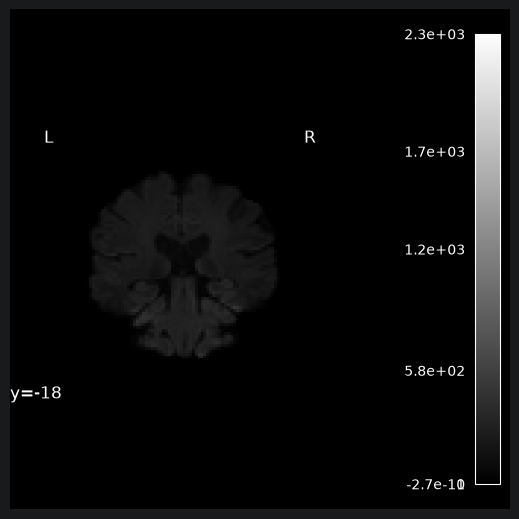

In [39]:
# Получение пути к dwi
dwi = without_lesion_df[without_lesion_df['label'] == 'dwi']['file_path'].item()

# Визуализация
visualize_one_slice(dwi, 'y', -18)

C:\Users\Герман\Desktop\projects\Stroke_segmetation_raw\src\visualization.py:17: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.plot_anat(patient_df[patient_df['label'] == label]['file_path'].item(),


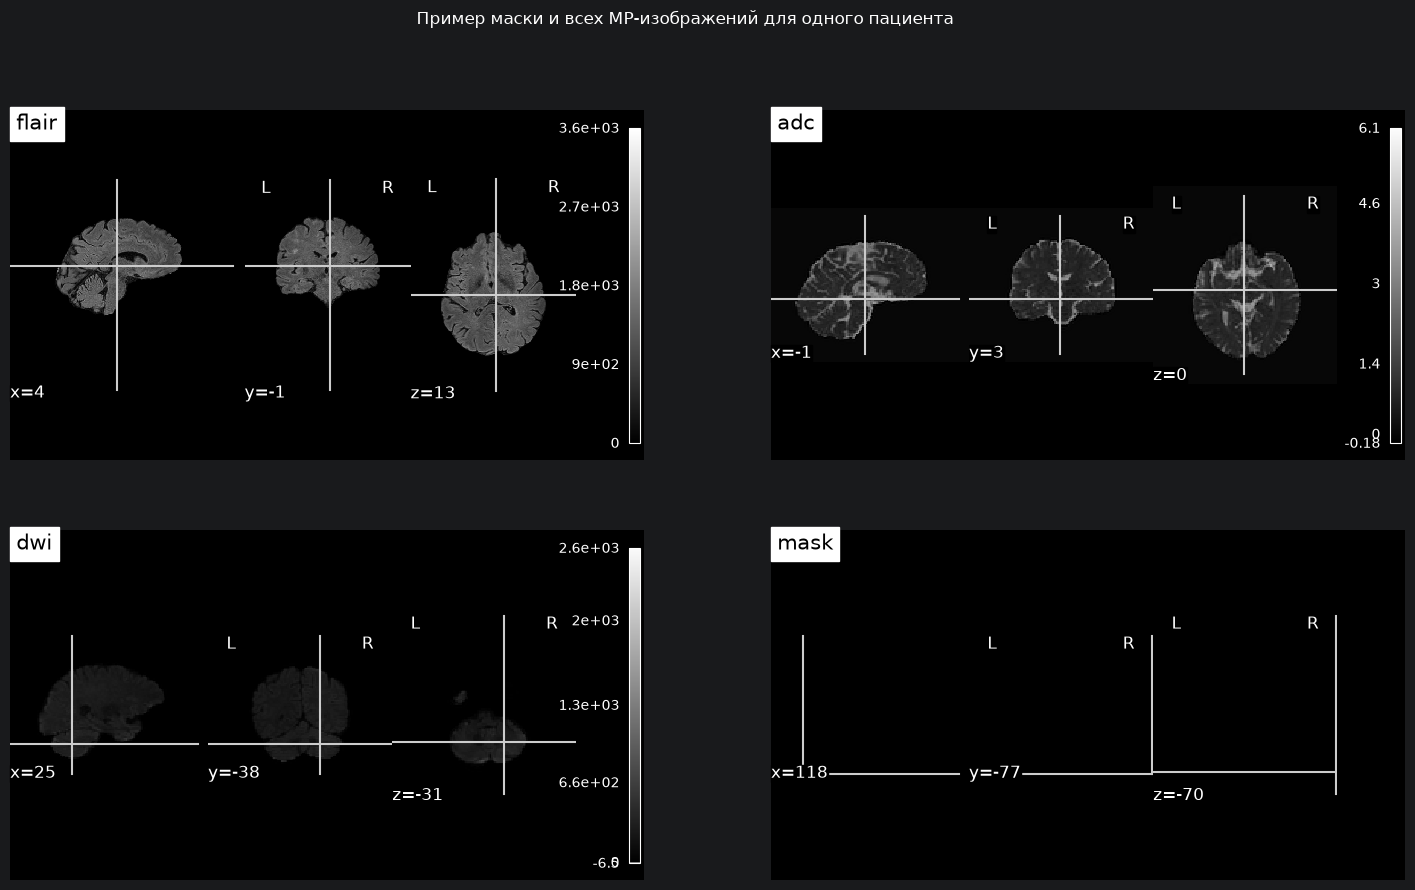

In [40]:
# Формирование датафрейма для пациента без очага
without_lesion_id = full_mask_df[full_mask_df['total_volume_cm3'] == 0].iloc[1, 1]
without_lesion_df = enriched_df[enriched_df['patient_id'] == without_lesion_id]

# Вывод всех снимков
visualize_all_patient_images(without_lesion_df)

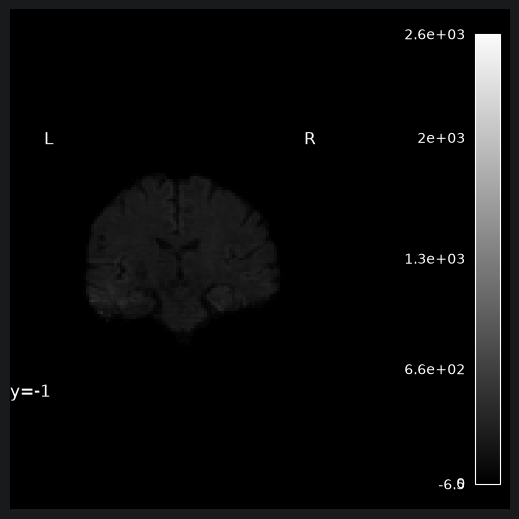

In [41]:
# Получение пути к dwi
dwi = without_lesion_df[without_lesion_df['label'] == 'dwi']['file_path'].item()

# Визуализация
visualize_one_slice(dwi, 'y', -1)

C:\Users\Герман\Desktop\projects\Stroke_segmetation_raw\src\visualization.py:17: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.plot_anat(patient_df[patient_df['label'] == label]['file_path'].item(),


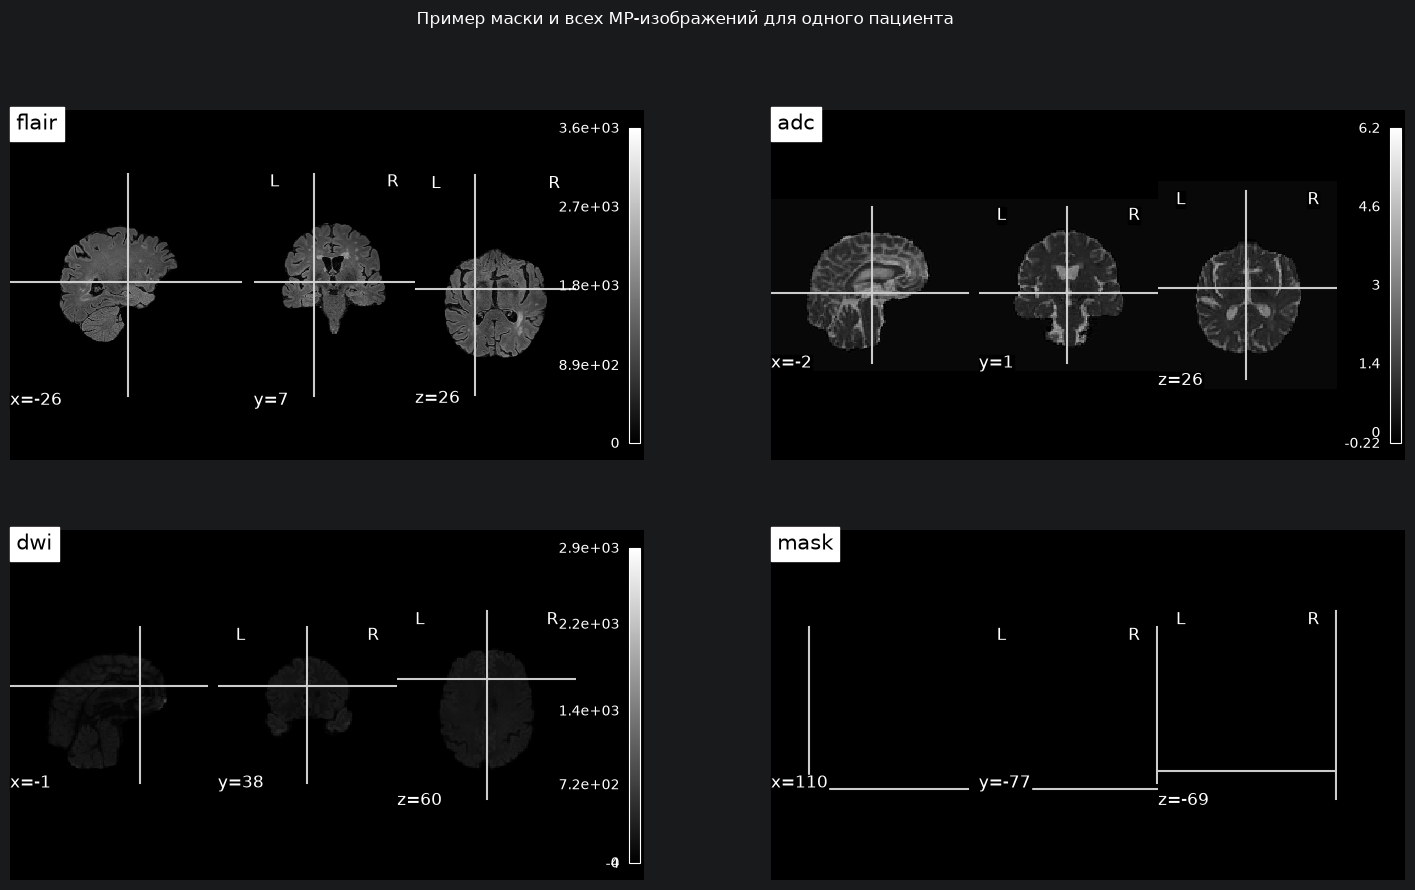

In [42]:
# Формирование датафрейма для пациента без очага
without_lesion_id = full_mask_df[full_mask_df['total_volume_cm3'] == 0].iloc[2, 1]
without_lesion_df = enriched_df[enriched_df['patient_id'] == without_lesion_id]

# Вывод всех снимков
visualize_all_patient_images(without_lesion_df)

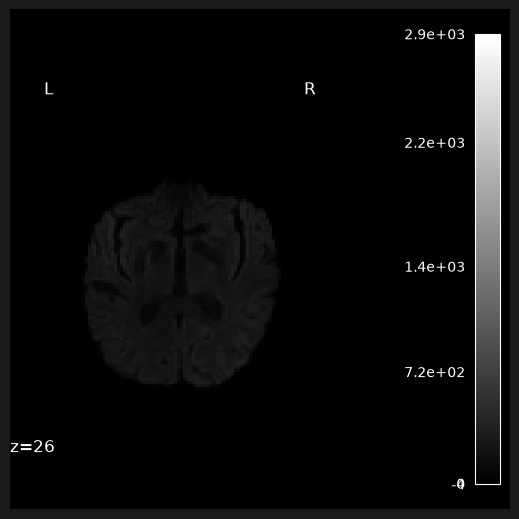

In [43]:
# Получение пути к dwi
dwi = without_lesion_df[without_lesion_df['label'] == 'dwi']['file_path'].item()

# Визуализация
visualize_one_slice(dwi, 'z', 26)

У всех 3 пациентов мозг визуализируется на всех изображениях. На визуализациях наблюдается несогласованность: разные протоколы для одного пациента визуализируются в разных анатомических областях, что связано или с разным положением пациента при сканировании или с разными настройками сканирования, что потребует приведения к единому пространственному положению. Также у первого, из визуализированных, пациента визуально отличается ADC снимок: фон является значительно более светлым, чем на других изображениях. Стоит провести анализ интенсивности ADC изображений

У всех пациентов наблюдаются зоны гиперинтенсивности на FLAIR снимках, которые не наблюдаются в тех же анатомических областях на DWI снимках, что говорит о том, что на FLAIR визуализируется либо хроническая стадия инсульта или иные заболевания головного мозга, что не свидетельствует о недостатках разметки данного датасета, ориентированного на острую и подострую стадии инсульта

### Анализ изображений в области сегментации

In [44]:
# Формируем датафрейм из статистических показателей распределения интенсивности
intensity_df = intensity_statistics(enriched_df)

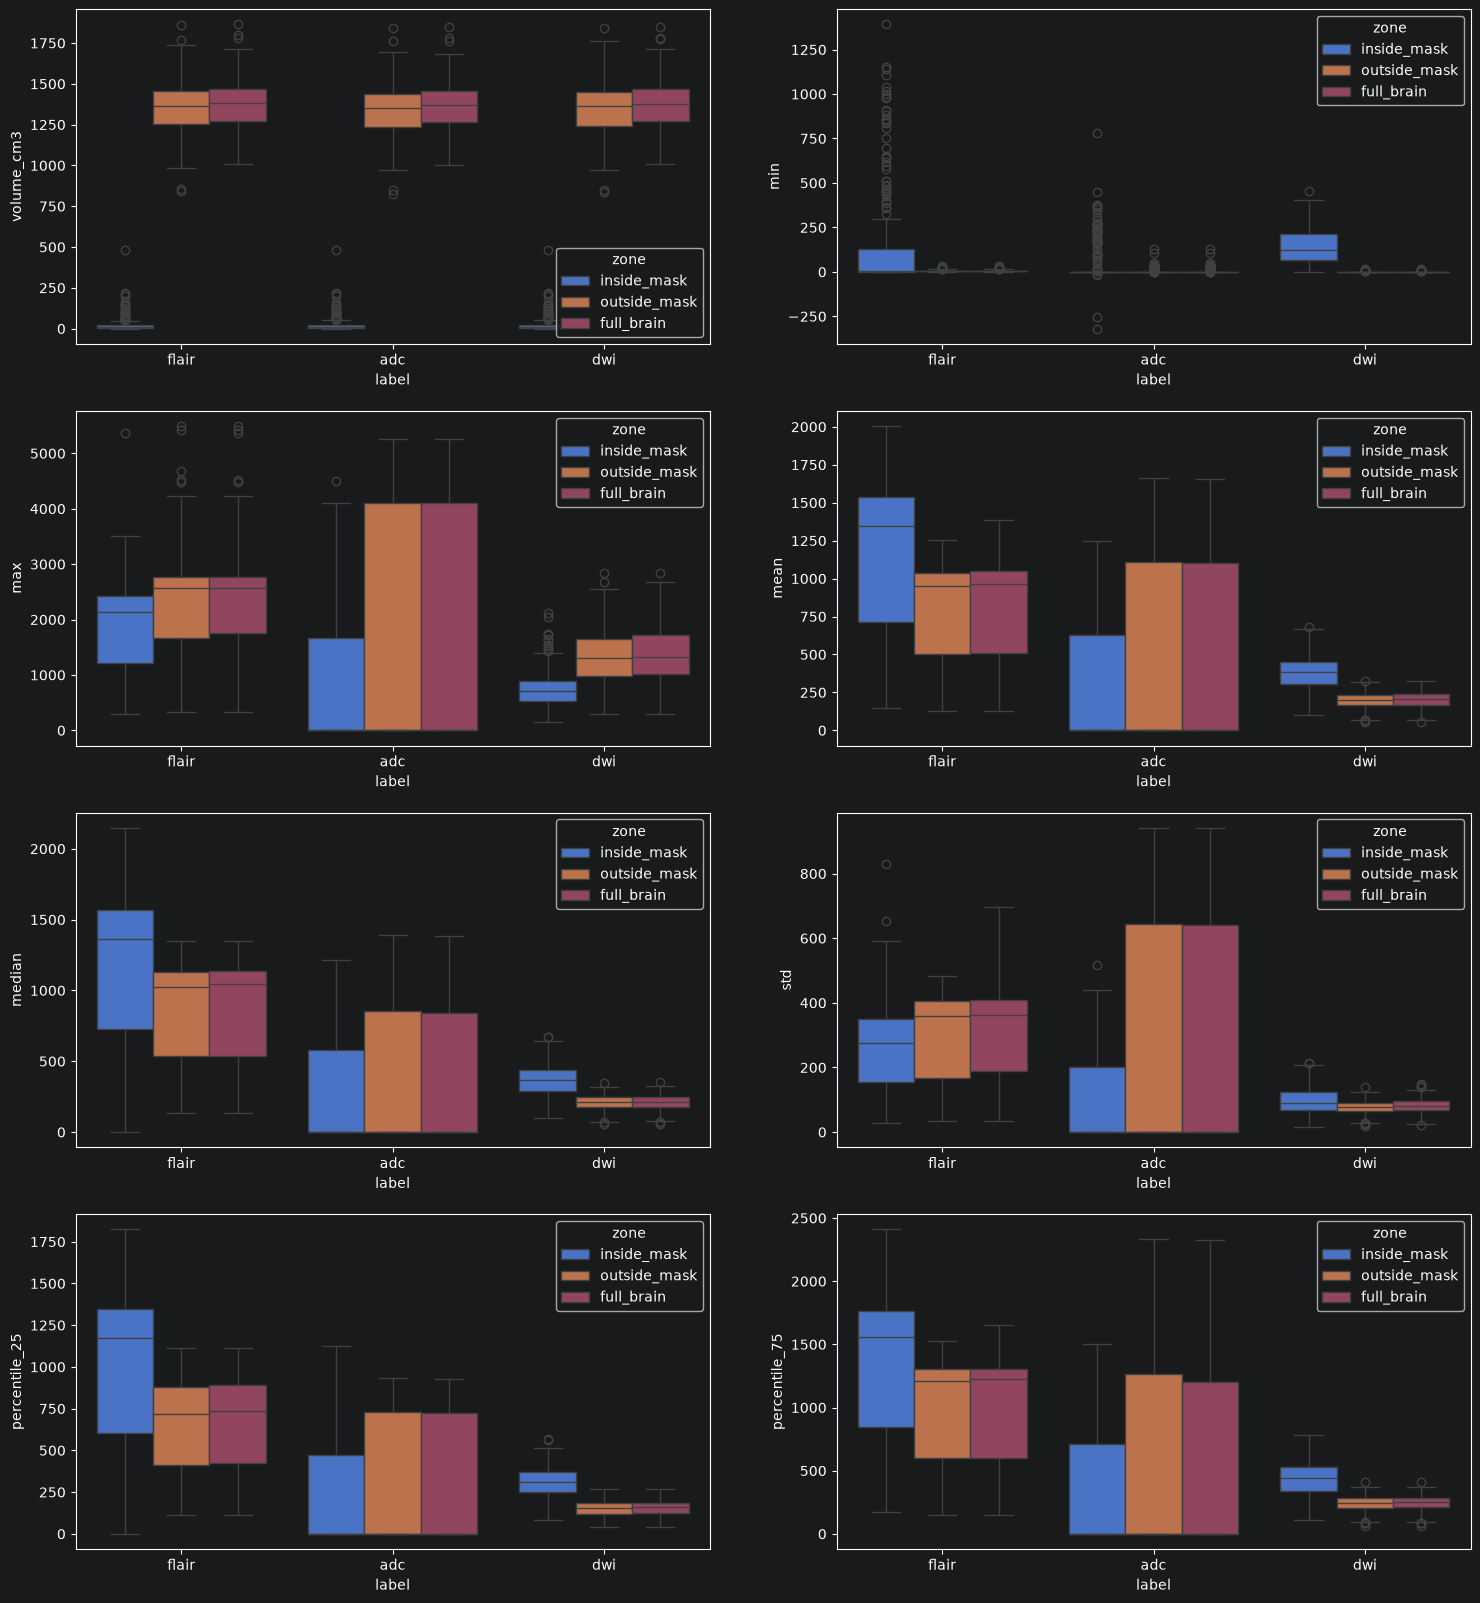

In [45]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))

for ax, col in zip(axes.flatten(), ['volume_cm3', 'min', 'max', 'mean', 'median', 'std', 'percentile_25', 'percentile_75']):
    sns.boxplot(data=intensity_df, x='label', y=col, hue= 'zone', ax=ax)
    ax.set_ylabel(col)

plt.show()

Исходя из проведенного анализа можно сказать, что:
1. В данных прослеживается заметный дисбаланс классов. Объемы поражений составляют малую часть общего объема мозга.
2. Отрицательные значения минимума интенсивности в поражении на ADC, вероятно, говорят о присутствии шума в изображениях.
3. На DWI изображениях характеристики распределения интенсивности в целом показывают меньшую вариативность внутри поражения, за его пределами и во всем мозге, в сравнении с ADC и FLAIR.
4. Заметное перекрытие распределений характеристик во всех областях на всех протоколах, вероятно, говорит о том, что в датасете представлено большое количество случаев ишемического инсульта небольшой силы, что согласуется с анализом масок сегментаций
5. Более высокие минимальные и средние значения интенсивности на DWI и FLAIR и более низкие максимальные и средние значения на ADC согласуются с логикой визуализации ишемического инсульта на данных протоколах
6. На DWI изображениях распределение характеристик внутри поражения заметнее отличается (по сравнению с ADC и FLAIR) от области за пределом поражения в сторону более высоких средних значений и перцентилей распределения (как и должно быть для DWI изображений), что говорит о том, что на DWI лучше визуализируется контраст ишемического поражения и здоровой ткани

Более подробно исследуем распределение медиан интенсивности всех протоколов на всем мозге

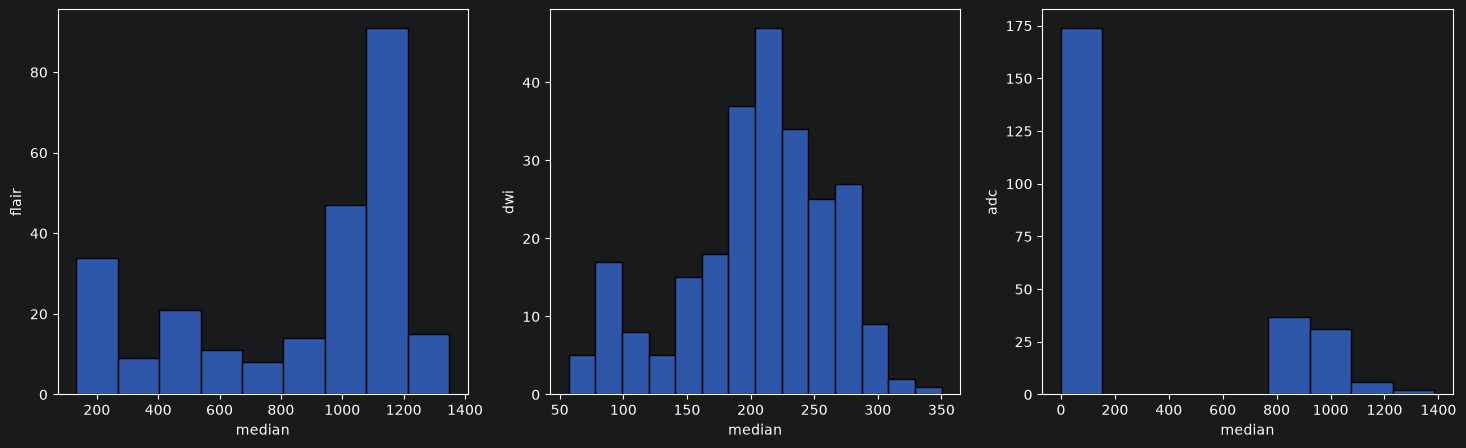

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, protocol in zip(axes.flatten(), ['flair', 'dwi', 'adc']):
    protocol_df = intensity_df[(intensity_df['label'] == protocol) & (intensity_df['zone'] == 'full_brain')]
    sns.histplot(data=protocol_df, x='median', ax=ax)
    ax.set_ylabel(protocol)

plt.show()

На распределениях медианы интенсивности для всего мозга на FLAIR и DWI изображениях обнаруживается пересечение двух распределений с пиками в значениях 200 и 1150 для FLAIR и - 80 и 220 для DWI. Несмотря на это, так как интенсивность обоих протоколов является качественным признаком (то есть важно не абсолютное значение интенсивности, а контраст интенсивности между очагом и здоровой тканью), помимо нормализации, дополнительной обработки интенсивности этих протоколов не потребуется

Для ADC изображений наблюдается, что по медианной интенсивности большинство из них близко к нулю, однако есть изображения, медианная интенсивность которых составляет более 1200. Так как интенсивность ADC изображений является количественным признаком, важно, чтобы интенсивность изображений выражалась одинаково

Чтобы не загружать данный обзор, я не буду визуализировать промежуточные малоинформативные графики, а оговорюсь, что было обнаружено разделение ADC изображений на 3 группы, представленные ниже

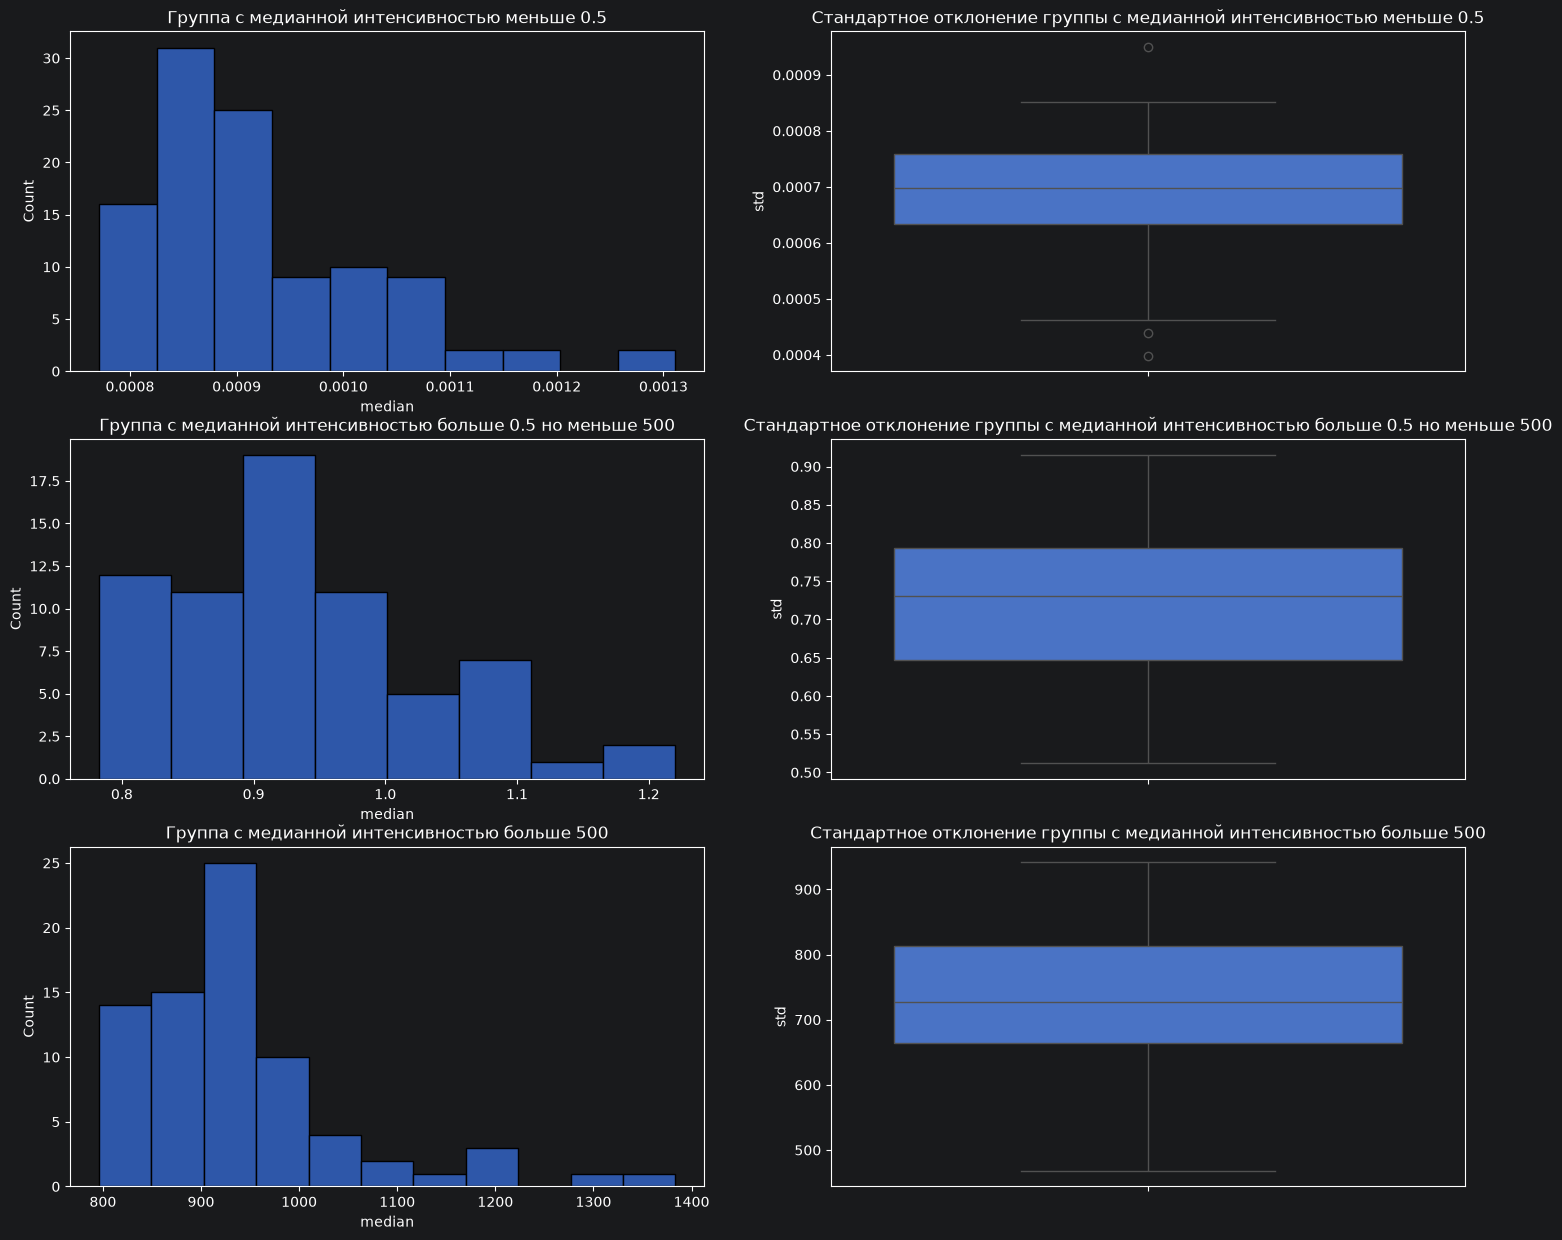

In [47]:
fig, axes = plt.subplots(3, 2, figsize=(18,15))
axes = axes.flatten()

adc_brain = intensity_df[(intensity_df['label'] == 'adc') & (intensity_df['zone'] == 'full_brain')]

low_adc_brain = adc_brain[adc_brain['median'] < 0.5]
sns.histplot(low_adc_brain['median'], ax=axes[0])
axes[0].set_title('Группа с медианной интенсивностью меньше 0.5')

sns.boxplot(low_adc_brain['std'], ax=axes[1])
axes[1].set_title('Стандартное отклонение группы с медианной интенсивностью меньше 0.5')


medium_adc_brain = adc_brain[(adc_brain['median'] > 0.5) & (adc_brain['median'] < 500)]
sns.histplot(medium_adc_brain['median'], ax=axes[2])
axes[2].set_title('Группа с медианной интенсивностью больше 0.5 но меньше 500')

sns.boxplot(medium_adc_brain['std'], ax=axes[3])
axes[3].set_title('Стандартное отклонение группы с медианной интенсивностью больше 0.5 но меньше 500')


large_adc_brain = adc_brain[adc_brain['median'] > 500]
sns.histplot(large_adc_brain['median'], ax=axes[4])
axes[4].set_title('Группа с медианной интенсивностью больше 500')

sns.boxplot(large_adc_brain['std'], ax=axes[5])
axes[5].set_title('Стандартное отклонение группы с медианной интенсивностью больше 500')

plt.show()

Учитывая, что группы ADC изображений по медианной интенсивности находятся в границах близких значений разных порядков, а стандартное отклонение у каждой группы находятся в пределах значений того же порядка, что и медианные интенсивности этих групп, можно заключить, что интенсивность на изображениях разных групп выражена разными единицами измерения. Это объясняет значительную вариативность характеристик распределения интенсивности для ADC в целом, а также различия в визуализациях разных ADC изображений

Учитывая, что группы различаются порядками, нормализация отдельных изображений нивелирует данное разделение

### Выводы

В данном датасете представлены МР-изображения 247 пациентов с ишемическим инсультом и 3 пациентов без него. Для каждого пациента имеются FLAIR, DWI и ADC снимки, а также маска сегментации ишемического поражения (для пациентов без инсульта - маски пустые). МР-изображения различаются по размерам, объему вокселей, интенсивности, матрице преобразований и типу данных как внутри групп снимков, так и между группами. То же самое относится и к маскам сегментаций. Ишемические поражения варьируются по объемам и количеству очагов, а данные о клинической ситуации такие, как локализации окклюзии сосудов у пациентов, факт реперфузии сосудов и временные метки МРТ-сканирования после начала ишемического эпизода отсутствуют.

#### Стратификация разбиения на подвыборки

Для стратификации разбиения пациентов на подвыборки было принято решение объединить признаки размера (на малые и крупные, используя в качестве порога медиану объема очагов) и количества очагов (без поражения, один очаг, множественные очаги)

In [48]:
df_to_split = build_dataframe_to_split()
df_to_split[df_to_split['label'] == 'mask']['lesion_label'].value_counts()

lesion_label
multiple_mixed_lesion         167
one_large_lesion               42
multiple_only_large_lesion     36
no_lesion                       3
multiple_only_small_lesion      2
Name: count, dtype: int64

Пациенты разделены на группы неравномерно. Больше всего пациентов представлено в группе множественных очагов смешанного объема, составляя 67% от общего числа пациентов.

Пациенты с одним очагом небольшого объема отсутствуют, а пациенты с одним крупным очагом составляют 17% от общего числа пациентов. Учитывая, что порог разделения крупных и мелких очагов производился по медиане данного датасета, а не по клинической границе, это говорит о том, что данный датасет сильно смещен в сторону случаев инсульта эмболического генеза, так как, согласно статистике, случаи инсульта, представленные одним очагом составляют 45-50% от всех случаев инсульта.

Количество пациентов без поражения равно 3. Снимки этой группы пациентов могут помочь посмотреть, будет ли модель производить сегментацию для пациентов у которых нет очага поражения. Однако опираться на метрики сегментации для данной группы для полноценной оценки способности модели не производить сегментацию для пациентов без ишемии не представляется возможным. То же самое относится и к группе пациентов с множественными мелкими очагами.

#### Трансформации изображений

Основываясь на проведенном EDA, потребуются следующие трансформации изображений и масок:
* минимизация шума на изображениях;
* приведение к единой ориентации в пространстве;
* проведение ресемплинга изображений и масок (привести к единому объему вокселя);
* нормализация интенсивности изображений;
* патчинг изображений (для получения одинаковых размеров и снижения затрат на GPU);
* приведение изображений и масок к единым типам данных (отдельно для масок и изображений);

#### Аугментации изображений

При условии, что из тренировочных изображений будут вырезаться патчи, для вторых выбраны следующие аугментации:
* Случайный поворот в пределах 15 градусов по всем осям
* Отражение по осям X, Y и Z. Так как при патчинге модель не сможет опираться на общую анатомию мозга, отражения по всем осям допустимы
* Добавление гаусового шума, для борьбы с переобучением
* Изменение контрастности, так как степень изменения интенсивности в очаге инсульта зависит от большого количества факторов и может быть разной у случаев инсульта схожего генеза

#### Наборы протоколов, выбранные для проведения экспериментов:

* DWI + ADC

Так как ADC является производным от DWI и несет дополнительные, согласованные с DWI, признаки, то использование этих протоколов в совокупности, потенциально дает, обученной на них модели, лучшее качество в сравнении с моделями, обученными только на ADC или DWI

* DWI + ADC + FLAIR

Обучение модели исключительно на FLAIR не представляется рациональным для сегментации очага инсульта на острой и подострой стадиях по причине того, что на FLAIR визуализируются зона пенумбры и очаги хронического инсульта. По этой причине данный протокол будет добавлен к ADC и DWI для оценки того, несет ли FLAIR дополнительные полезные признаки для данной задачи

#### Выбранные архитектуры моделей сегментации:

* 3D U-Net: Используется, как базовая модель сегментации 3D изображений.
* Attention 3D U-net: Ожидается более высокая точность на очагах малого объема, за счет механизма внимания
* 3D U-net++: Ожидаются более высокие: соответствие границ сегментации и очага; точность на очагах малого объема за счет плотных вложенных связей
* Swin UNETR: Ожидается более высокая точность на очагах малого объема, а также интересно посмотреть, как с этой задачей справится трансформер

В качестве функции потерь будет использоваться DiceFocalLoss за счет чувствительности к небольшим объектам на изображении
В качестве оптимизатора будет использоваться AdanW, так как он лучше борется с переобучением, чем Adam
В качестве планировщика скорости обучения будет использоваться ReduceLROnPlateau, отслеживая коэффициент Дайса на валидационной выборке
Ранняя остановка обучения модели будет реализована также на основе коэффициента Дайса на валидационной выборке